<a href="https://colab.research.google.com/github/TeraneAgaeva/python_for_ds_tasks/blob/main/Agaeva__%22HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [568]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [569]:
!ls /content/drive/MyDrive/ML/ML_module_2.2

medical-charges.csv


In [570]:
import pandas as pd
import numpy as np
medical_df = pd.read_csv('/content/drive/MyDrive/ML/ML_module_2.2/medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

# Завдання 1

**1.1. Метод найменших квадратів (Least Squares Method):**

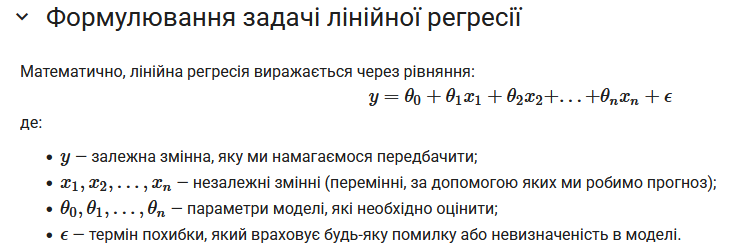

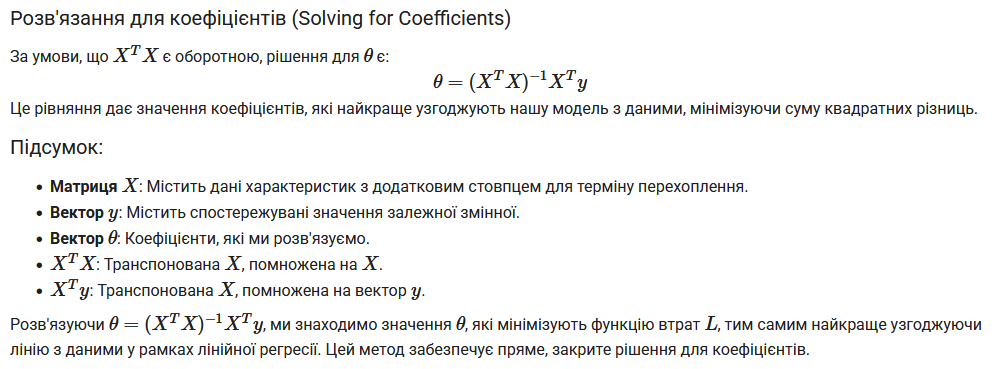

In [571]:
import matplotlib.pyplot as plt


In [572]:
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [573]:
non_smoker_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1064 entries, 1 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1064 non-null   int64  
 1   sex       1064 non-null   object 
 2   bmi       1064 non-null   float64
 3   children  1064 non-null   int64  
 4   smoker    1064 non-null   object 
 5   region    1064 non-null   object 
 6   charges   1064 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.5+ KB


In [574]:
x = non_smoker_df[['age']].values
max(x)

array([64])

In [575]:
y = non_smoker_df[['charges']].values

In [576]:
#нормальне рівняння - метод найменших квадратів - розраховує коефіцієнти лінійної регресії:

def normal_equations(x,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(x.T.dot(x)).dot(x.T).dot(y)
    return theta

In [577]:
# Додаємо колонку одиничок аби задачи bias терм (константу в моделі регресії)
x_with_intercept = np.c_[np.ones((x.shape[0], 1)), x] # np.ones() создает новый массив, заполненный единицами. np.c_ - это удобная функция NumPy для объединения (конкатенации) массивов по столбцам.
x[:3], x_with_intercept[:3]

(array([[18],
        [28],
        [33]]),
 array([[ 1., 18.],
        [ 1., 28.],
        [ 1., 33.]]))

In [578]:
MNK_coefs = normal_equations(x_with_intercept, y) # коефіцієнти лінійної регресії, це вектор (або матриця) коефіцієнтів лінійної регресії. Має форму (2,1)
print(MNK_coefs)

[[-2091.42055657]
 [  267.24891283]]


Ці два числа є коефіцієнтами нашої лінійної регресійної моделі. Вони визначають рівняння прямої лінії, яке найкраще прогнозує страхові збори:

Predicted charges = -2091.42 + 267.25 * age

Ми проаналізуємо кожне число:

**-2091.42 (перше значення, вільний член/intercept) - MNK_coefs[0] :**

Це основна сума страхових зборів, коли вік становить 0 (тобто точка, де лінія перетинає вісь Y).

У цьому контексті негативне значення -2091.42 означає, що без врахування віку (або з його мінімальними значеннями) прогнозовані основні збори можуть бути «умовним» негативним числом, яке не має прямого фізичного значення в реальних зборах (вони не можуть бути негативними). Це часта ситуація для коефіцієнта переміщення, коли дані не включають значення, близькі до нуля, або коли модель просто найкраще підходить до діапазону ваших даних.

**267,25 (друге значення, коефіцієнт при "віці") - MNK_coefs[1] :**

Це коефіцієнт нахилу. Це показує, як в середньому страхові збори змінюються зі збільшенням віку на один рік.

Позитивна вартість 267,25 означає, що з кожним додатковим роком прогнозованих страхових зборів за середнє збільшення приблизно на 267,25 одиниць.

**Підсумок:** Ця лінійна регресійна модель говорить про те, що існує пряма залежність: чим старша людина, тим вище його прогнозовані страхові збори, з певною основною відправною точкою.

In [579]:
predictions_MNK = np.dot(x_with_intercept, MNK_coefs)
print(predictions_MNK)

[[2719.0598744 ]
 [5391.54900271]
 [6727.79356686]
 ...
 [2719.0598744 ]
 [2719.0598744 ]
 [3520.80661289]]


**predictions_MNK[i] = MNK_coefs[0] * 1 + MNK_coefs[1] * x_with_intercept[i, 1]**

де:

    MNK_coefs[0] - це вільний член (intercept).

    MNK_coefs[1] - це коефіцієнт при ознаці (вік).

    x_with_intercept[i, 1] - це значення віку для i-го спостереження.

In [580]:
# зробимо порівняння фактичних значень з прогнозованими для перших 10 записів

predictions_MNK[:10], y[:10]

(array([[ 2719.0598744 ],
        [ 5391.54900271],
        [ 6727.79356686],
        [ 6460.54465403],
        [ 6193.2957412 ],
        [10202.02943367],
        [ 7796.78921819],
        [ 7796.78921819],
        [13943.51421331],
        [ 4589.80226421]]),
 array([[ 1725.5523 ],
        [ 4449.462  ],
        [21984.47061],
        [ 3866.8552 ],
        [ 3756.6216 ],
        [ 8240.5896 ],
        [ 7281.5056 ],
        [ 6406.4107 ],
        [28923.13692],
        [ 2721.3208 ]]))

Бачимо, що для третьої позиції прогнозні дані завеликі

In [581]:
np.std(predictions_MNK), np.std(y)

(np.float64(3762.0069084528054), np.float64(5990.9645302876115))

In [582]:
np.min(predictions_MNK), np.min(y)

(np.float64(2719.059874396516), np.float64(1121.8739))

In [583]:
np.max(predictions_MNK), np.max(y)

(np.float64(15012.509864631706), np.float64(36910.60803))

In [584]:
np.mean(predictions_MNK), np.mean(y)

(np.float64(8434.268297856215), np.float64(8434.268297856204))

In [585]:
np.dot(x_with_intercept[0], MNK_coefs)

array([2719.0598744])

In [586]:
np.dot(x_with_intercept[2], MNK_coefs)

array([6727.79356686])

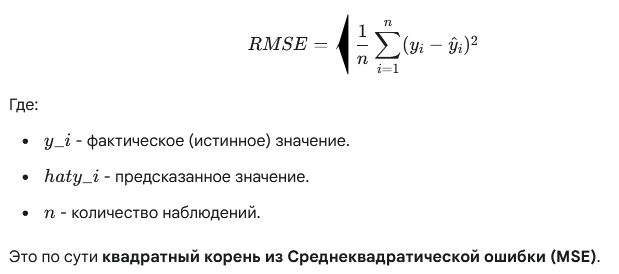

In [587]:
RMSE = np.sqrt(np.mean(np.square(y - predictions_MNK)))
RMSE

np.float64(4662.505766636395)

**RMSE показує, що в середньому відхилення значень на 4662.** При мінімумі у факті 1121 та максимумі у факті 36910. Похибка в декілька разів більша мінімума, а передбачення по максимуму відрізняється більше ніж у двічі 15012 прогноз та 36910 факт - такі відхилення є дуже великими. Можливі причини неточності моделі: є викиди, дуже проста модель, розглянути варіант що можливо у даних відсутня лінійна залежність, чи для моделі потрібно розглянути інші незалежні змінні.

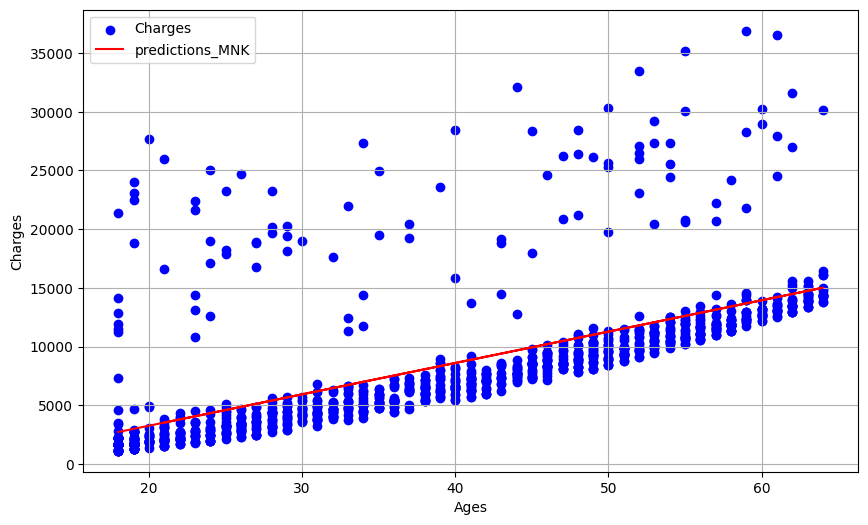

In [588]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], y, color='blue', label='Charges')
plt.plot(x[:, 0], predictions_MNK, color='red', label='predictions_MNK')
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

**Висновок щодо графіку 1.1.:** ми бачимо на графіку дійсно є присутня лінійна залежність, але також є викиди які потрібно проаналізувати додатково та прийняти рішення щодо їх усунення

**1.2. Full-Batch градієнтного спуску з numpy:**

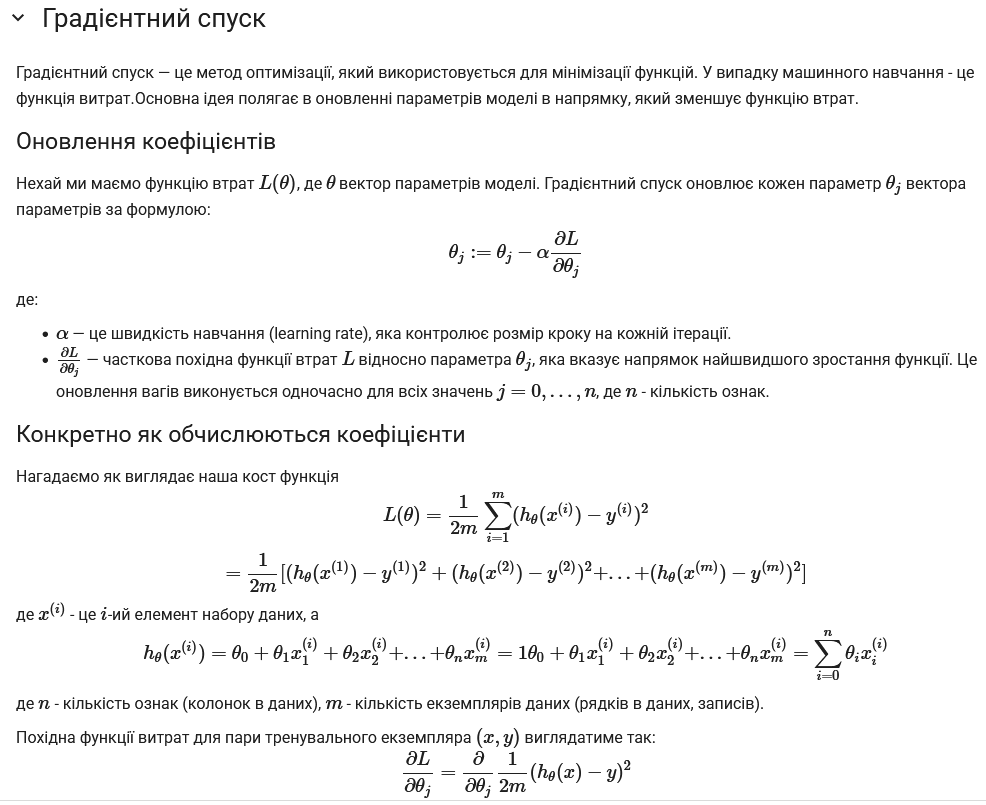

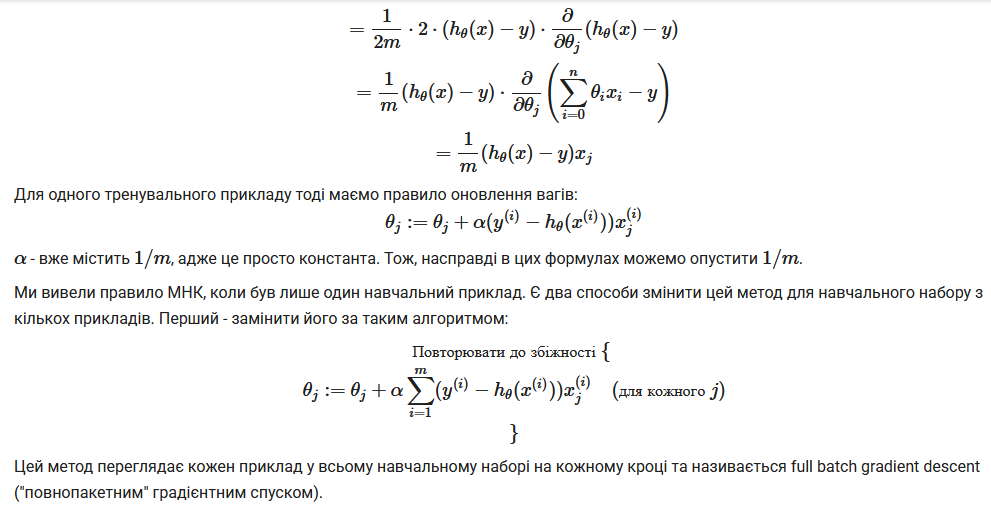

In [589]:
y = non_smoker_df[['charges']].values.flatten()
print(y.shape[0])

1064


In [590]:
#x = non_smoker_df[['age']].values.flatten()
y_flatten = non_smoker_df[['charges']].values.flatten()  # .flatten() чтобы y был одномерным, если он 2D. Було так [[18], [28], [33]], стане [18, 28, 33]

# Градієнтний спуск
def full_batch_gradient_descent(x, y_flatten, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y_flatten)
    errors = []
    for _ in range(epochs):
        y_pred = m * x[:, 0] + b
        error = y_pred - y_flatten
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, x[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

m, b, errors = full_batch_gradient_descent(x, y_flatten, lr=0.0001, epochs=1000)
predictions_fbgd = m * x[:, 0] + b

print(f"m: {m}")
print(f"b: {b}")
print(f"predictions_fbgd: {predictions_fbgd}")

m: 221.1045843794301
b: -41.98126853149978
predictions_fbgd: [3937.9012503  6148.94709409 7254.47001599 ... 3937.9012503  3937.9012503
 4601.21500344]


In [591]:
predictions_fbgd[:10], y_flatten[:10] #порівняння передбачення з фактом

(array([ 3937.9012503 ,  6148.94709409,  7254.47001599,  7033.36543161,
         6812.26084723, 10128.82961292,  8138.88835351,  8138.88835351,
        13224.29379423,  5485.63334095]),
 array([ 1725.5523 ,  4449.462  , 21984.47061,  3866.8552 ,  3756.6216 ,
         8240.5896 ,  7281.5056 ,  6406.4107 , 28923.13692,  2721.3208 ]))

In [592]:
RMSE_fbgd = np.sqrt(np.mean(np.square(y_flatten - predictions_fbgd)))
RMSE_fbgd

np.float64(4713.250582815521)

**Висновок 1.2.:** Ця лінійна регресійна модель говорить про те, що існує пряма залежність: чим старша людина, тим вище його прогнозовані страхові збори, з певною основною відправною точкою. Це видно з показника m = 221. Проте співставивши передбачені значення з фактичними ми бачимо, що 3й запис фактичний 21984 а прогнозний 7254, що говорить про недосконалість моделі чи про викиди. Аналізувавши вище графік, ми бачили, що є викиди - це може суттєво впливати, тому в подальшому аналізі викики потрібно викинути і повторити розрахунок. В цілому дані показників m та b на перший погляд виглядають адекватно але для цього lr=0.0001 темп навчання потрібно було зменшити з 0.1 (абоlearning rate). Для отримання більш точних даних необхідвно виконати: перевірку на викиди, розглянути можливість використання нелінійної моделі (але в графіку п1.2 ми бачимо лінійну залежність), в розрахунку використовувати ще інші параметри наприклад маса тіла, використати більш складну модель.
**RMSE показує**, що в середньому відхилення значень на 4713. При мінімумі у факті 1121 та максимумі у факті 36910. Похибка в декілька разів більша мінімума

In [593]:
y_hat = b + x*m

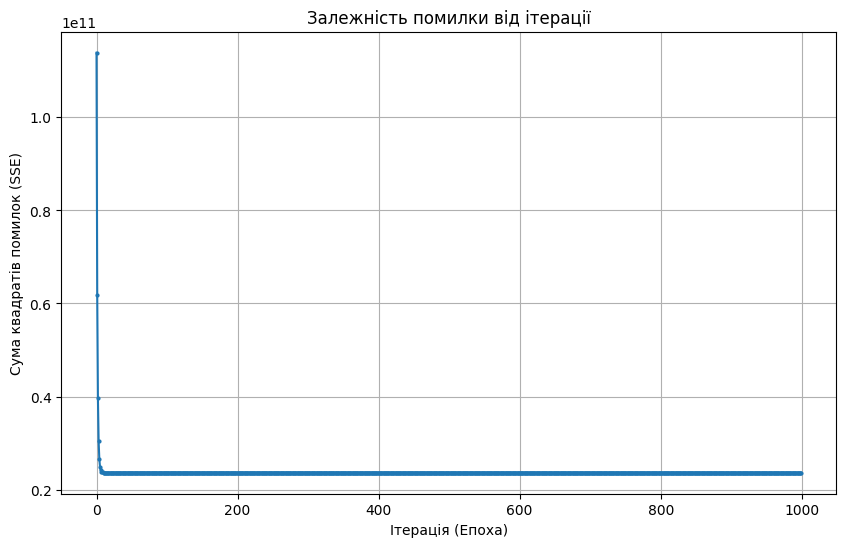

In [594]:
# После выполнения градиентного спуска:
plt.figure(figsize=(10, 6)) # Создаем фигуру для графика
plt.plot(range(len(errors)), errors, marker='o', markersize=2) # Строим график
plt.title('Залежність помилки від ітерації') # Название графика
plt.xlabel('Ітерація (Епоха)') # Подпись оси X
plt.ylabel('Сума квадратів помилок (SSE)') # Подпись оси Y
plt.grid(True) # Включаем сетку
plt.show() # Показываем график

**Висновок щодо графіку 1.2:**

Ось як інтерпретувати цей графік:

**Різке початкове падіння помилки:** На початку (на перших кількох ітераціях, можливо, до 50-100) ви бачите дуже різке зниження помилки. Це означає, що модель швидко знайшла напрямок для покращення і значно зменшила свої початкові, дуже великі помилки.

**Високе початкове значення помилки:** Стартова помилка дуже велика (вище 1e11). Це нормально початку навчання, коли параметри m і b ініціалізовані нулями чи випадковими малими значеннями, і модель ще " знає " залежність у даних.

**Вихід на плато/Східність:** Після різкого падіння, крива помилки швидко виходить на плато і залишається практично рівною до кінця навчання (до 1000 ітерацій). Це свідчить, що градієнтний спуск зійшовся. Модель досягла стану, коли подальші ітерації з поточним темпом навчання (lr) не призводять до значного зменшення помилки.

**Кінцевий рівень помил**ки: Помилка стабілізувалася на рівні приблизно 0.22*1e11, тобто близько 2.2*10^10. Це означає, що хоча модель і зійшлася, залишкова помилка все ще досить велика.

In [595]:
# визначаємо змінні для рівняння:
b = MNK_coefs[0, 0]  # Первый элемент, первая строка, первый столбец
m = MNK_coefs[1, 0]  # Второй элемент, вторая строка, первый столбец

print(f"Значення b (вільний член): {b}")
print(f"Значення m (коефіцієнт при ознаці): {m}")

Значення b (вільний член): -2091.4205565650805
Значення m (коефіцієнт при ознаці): 267.2489128311998


**1.3. scikit-learn.LinearRegression**

In [596]:
!pip install scikit-learn --quiet

In [597]:
from sklearn.datasets import make_regression

In [598]:
from sklearn.linear_model import LinearRegression

In [599]:
# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()

In [600]:
lin_reg.fit(x, y)

LinearRegression()

In [612]:
lin_reg.coef_, lin_reg.intercept_

(array([[305.23760211]]), array([20294.12812692]))

In [615]:
predictions_sklearn = lin_reg.predict(x)
predictions_sklearn

array([[25788.40496489],
       [28840.78098599],
       [30366.96899654],
       ...,
       [25788.40496489],
       [25788.40496489],
       [26704.11777122]])

In [603]:
RMSE_skl = np.sqrt(np.mean(np.square(y - predictions_sklearn)))
RMSE_skl

np.float64(4662.505766636395)

**Висновок 1.3.:** Прогнозні значення та похибка дуже близькі до розрахунків п 1.2.

In [604]:
print("Перевірка розміру даних:")

# Для x (якщо це 2D масив, наприклад, (1064, 1))
if x.ndim > 1:
    print(f"Розмір x (кількість елементів): {x.shape[0]}")
else: # Если x одномерный (например, (1064,))
    print(f"Розмір x (кількість елементів): {x.shape[0]}")

print(f"Розмір у (кількість елементів): {y_flatten.shape[0]}")

# Перевірка передбачень
# Важливо запевнитись, що ці змінні існують перед перевіркою
if 'predictions_MNK' in locals(): # Перевіряєм чи визначена змінна
    print(f"Розмір predictions_MNK: {predictions_MNK.shape[0]}")
else:
    print("predictions_MNK не визначена.")

if 'predictions_fbgd' in locals():
    print(f"Розмір predictions_fbgd: {predictions_fbgd.shape[0]}")
else:
    print("predictions_fbgd не визначена.")

if 'predictions_sklearn' in locals():
    print(f"Розмір predictions_sklearn: {predictions_sklearn.shape[0]}")
else:
    print("predictions_sklearn не визначена.")

Перевірка розміру даних:
Розмір x (кількість елементів): 1064
Розмір у (кількість елементів): 1064
Розмір predictions_MNK: 1064
Розмір predictions_fbgd: 1064
Розмір predictions_sklearn: 1064


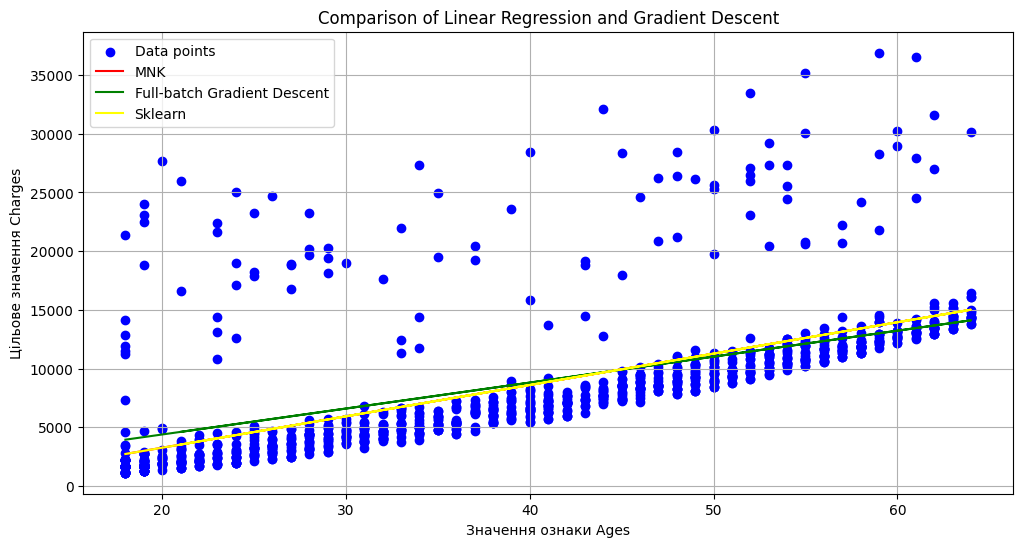

In [605]:
# Візуалізація результатів по методу найменьших квадратів, градієнтний спуск та градієнтний спуск sklearn
plt.figure(figsize=(12, 6))
plt.scatter(x[:, 0], y, color='blue', label='Data points')
plt.plot(x[:, 0], predictions_MNK, color='red', label='MNK')
plt.plot(x[:, 0], predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(x[:, 0], predictions_sklearn, color='yellow', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки Ages')
plt.ylabel('Цільове значення Charges')
plt.legend()
plt.grid(True)
plt.show()

**Висновок щодо графіку 1.3:** Передбачення predictions_MNK співпали з  predictions_sklear, це добре адже може говорити про вірність моделі, адже розрахунок різними способами дає той самий результат. Це видно якщо закмоентувати #plt.plot(x[:, 0], predictions_sklearn, color='yellow', label='Sklearn'). Ми бачимо що лінія червона predictions_MNK під лінією жовтою predictions_sklearn. Взагалі усі три методи практично збігаються, що говорить про те, що всі три методи зійшлися до дуже схожого рішення. Але не дивлячись на схожість розрахунків в моделях - моделі погано пояснюють дані. Можливо потрібно більше критеріїв та викинути викиди, чи застосувати більш складну модель

In [606]:
from sklearn.datasets import make_regression

# Градієнтний спуск
def full_batch_gradient_descent(x_with_intercept, y, lr=0.1, epochs=100):
    # Теперь m и b будут частью одного вектора параметров theta
    # Изначально theta будет [b_initial, m_initial]
    theta = np.array([[0.0], [0.0]]) # Начальные параметры для b и m

    n = len(y)
    errors = []

    for _ in range(epochs):
        # y_pred = m * x[:, 0] + b  <-- ЭТУ СТРОКУ НУЖНО ИЗМЕНИТЬ
        y_pred = np.dot(x_with_intercept, theta) # Правильное матричное умножение

        error = y_pred - y.reshape(-1, 1) # Убедимся, что y имеет форму (n, 1) для вычитания

        # Сумма квадратов ошибок
        errors.append(np.sum(error**2))

        # Градиенты для ВСЕХ параметров (b и m)
        # Формула градиента для линейной регрессии в матричной форме:
        # gradient = (2/n) * X.T @ (X @ theta - y)
        gradients = (2/n) * np.dot(x_with_intercept.T, error)

        # Обновление параметров
        theta = theta - lr * gradients

        # Опционально: добавить проверку на nan, чтобы остановить процесс раньше
        if np.isnan(theta).any(): # Проверяем, есть ли nan в любом из параметров
            print(f"Остановка: NaN появился на эпохе {_}")
            break

    # Возвращаем b и m из вектора theta
    m_final = theta[1, 0] # Коэффициент для признака
    b_final = theta[0, 0] # Свободный член

    return m_final, b_final, errors


# Пример использования (предполагается, что 'x' и 'y' уже определены)
# ВАЖНО: передаем x_with_intercept в функцию
# x_with_intercept = np.c_[np.ones((x.shape[0], 1)), x] # Это должно быть сделано перед вызовом функции
# Убедитесь, что y имеет правильную форму (столбец) для операций
# y_reshaped = y.reshape(-1, 1) # y изначально одномерный массив

# Пример данных (как в вашем make_regression)
# (Для запуска функции, если у вас нет глобальных x и y)
X_synth, y_synth, _ = make_regression(n_samples=100, n_features=1, bias=4, noise=20, coef=True, random_state=42)
X_synth_with_intercept = np.c_[np.ones((X_synth.shape[0], 1)), X_synth]
y_synth_reshaped = y_synth.reshape(-1, 1) # Преобразуем y в столбец

m_gd, b_gd, errors_gd = full_batch_gradient_descent(X_synth_with_intercept, y_synth_reshaped, lr=0.0001, epochs=1000)

predictions_fbgd = m_gd * X_synth[:, 0] + b_gd

print(f"Найденные m (GD): {m_gd}")
print(f"Найденные b (GD): {b_gd}")
# print("Первые 5 предсказаний GD:", predictions_fbgd[:5])

Найденные m (GD): 7.070178254794621
Найденные b (GD): 0.3307785311247708


# Завдання 2

In [607]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [609]:
# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg2 = LinearRegression()

In [610]:
x_sm = smoker_df[['age']].values
y_sm = smoker_df[['charges']].values

In [611]:
lin_reg.fit(x_sm, y_sm)

LinearRegression()

In [614]:
lin_reg.coef_, lin_reg.intercept_

(array([[305.23760211]]), array([20294.12812692]))

In [622]:
predictions_sklearn_sm = lin_reg.predict(x_sm)
predictions_sklearn_sm

array([[26093.642567  ],
       [39218.85945773],
       [28535.54338388],
       [29451.25619021],
       [30672.20659865],
       [29756.49379232],
       [27009.35537333],
       [28840.78098599],
       [30977.44420076],
       [38608.38425351],
       [31282.68180287],
       [34945.53302819],
       [31282.68180287],
       [37997.90904929],
       [25788.40496489],
       [36471.72103874],
       [26398.88016911],
       [28840.78098599],
       [28535.54338388],
       [27009.35537333],
       [31587.91940498],
       [34029.82022186],
       [37692.67144718],
       [38303.1466514 ],
       [39829.33466195],
       [37387.43384507],
       [31893.15700709],
       [38913.62185562],
       [26398.88016911],
       [39524.09705984],
       [29146.0185881 ],
       [33724.58261975],
       [26093.642567  ],
       [30061.73139443],
       [30672.20659865],
       [29451.25619021],
       [34335.05782397],
       [33114.10741553],
       [34945.53302819],
       [25788.40496489],


In [617]:
RMSE_skl_sm = np.sqrt(np.mean(np.square(y_sm - predictions_sklearn_sm)))
RMSE_skl_sm

np.float64(10711.00334810241)

In [618]:
max(y_sm)

array([63770.42801])

In [619]:
min(y_sm)

array([12829.4551])

In [620]:
np.mean(y_sm)

np.float64(32050.23183153284)

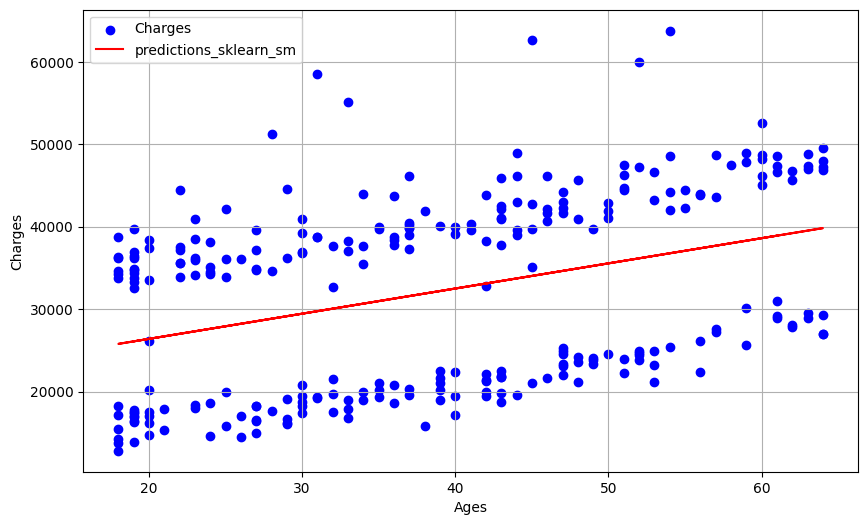

In [623]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(x_sm[:, 0], y_sm, color='blue', label='Charges')
plt.plot(x_sm[:, 0], predictions_sklearn_sm, color='red', label='predictions_sklearn_sm')
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

**Висновок 2:** Виходячи з наданих даних:

**RMSE **= 10711.00: Це середня помилка передбачення моделі. Кожне передбачення середньому відрізняється від фактичного значення на 10711 одиниць.

Діапазон та середнє значення charges:

**Мінімальне** charges = 12829.45.

**Максимальне** charges = 63770.43.

**Середнє** charges = 32050.23.

Порівняння RMSE із середнім значенням: RMSE (10711) становить приблизно 33% від середнього значення charges (32050). Це відносно висока помилка, що вказує на те, що модель не дуже точно передбачає медичні збори.

**На графіку **бачимо позитивну регресію, але модель не точна, адже в основном точки зосереджені над лінією та під лінією передбачення. Для покращення результатів потрібно розглянути ще декілька критеріїв